# Ringworm vs Healthy — Binary Classifier
MobileNetV2 transfer learning. Two-phase training: frozen base → fine-tuning.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1. Configuration

In [2]:
# ── Update this path to your dataset root ──────────────────────────────────
# Expected structure:
#   DATASET_PATH/
#     Healthy/   (your healthy skin images)
#     Ringworm/  (your ringworm images)

DATASET_PATH = r"C:\Users\dvill\OneDrive\Documents\Diego Villegas Personal\RingCheck Dataset"

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 16
EPOCHS_PHASE1 = 10   # frozen base
EPOCHS_PHASE2 = 10   # fine-tuning
SEED         = 42

CLASSES = ['Healthy skin', 'Ringworm']

print("Classes:", CLASSES)


Classes: ['Healthy skin', 'Ringworm']


## 2. Load & Split Dataset

In [3]:
from tensorflow.keras.utils import image_dataset_from_directory

# Training set (70%)
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASSES,
    label_mode='binary'
)

# Validation + test (30% split in half → 15% val, 15% test)
val_test_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASSES,
    label_mode='binary'
)

val_batches  = tf.data.experimental.cardinality(val_test_ds) // 2
val_ds       = val_test_ds.take(val_batches)
test_ds      = val_test_ds.skip(val_batches)

print(f"Train batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Val   batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test  batches: {tf.data.experimental.cardinality(test_ds)}")
print("Class names:", train_ds.class_names)


Found 330 files belonging to 2 classes.
Using 231 files for training.
Found 330 files belonging to 2 classes.
Using 99 files for validation.
Train batches: 15
Val   batches: 3
Test  batches: 4
Class names: ['Healthy skin', 'Ringworm']


## 3. Visualise Samples

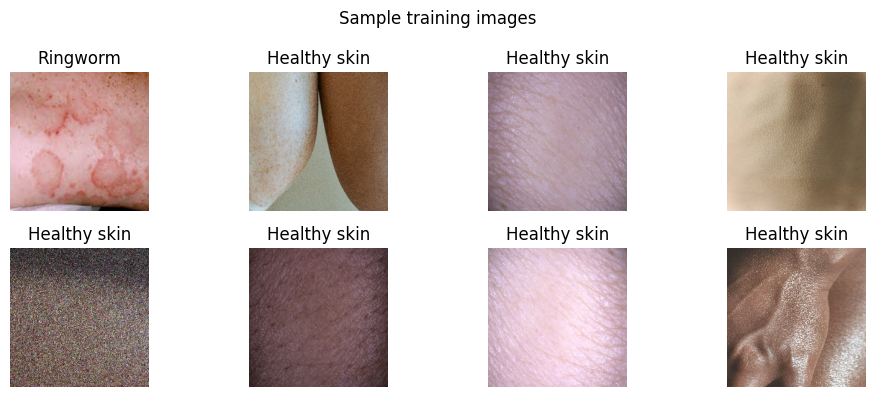

In [4]:
plt.figure(figsize=(10, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASSES[int(labels[i])])
        plt.axis('off')
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()


## 4. Data Augmentation & Preprocessing

In [5]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.GaussianNoise(0.05),
], name="augmentation")


## 5. Build Model — Phase 1 (Frozen Base)

In [9]:
# Load MobileNetV2 without top layers
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze all base layers

# Build classifier head
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # binary output

model = tf.keras.Model(inputs, outputs, name="ringworm_binary_classifier")
model.summary()

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_ds_aug = (
    train_ds
    .map(lambda x, y: (augmentation(x, training=True), y))
    .map(lambda x, y: (preprocess(x), y))
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds_prep = val_ds.map(lambda x, y: (preprocess(x), y)).cache().prefetch(AUTOTUNE)
test_ds_prep = test_ds.map(lambda x, y: (preprocess(x), y)).cache().prefetch(AUTOTUNE)

print("Preprocessing pipelines ready.")


Model: "ringworm_binary_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Preprocessing pipelines ready.


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Compiled. Starting Phase 1 training...")


Compiled. Starting Phase 1 training...


In [11]:
history1 = model.fit(
    train_ds_aug,
    validation_data=val_ds_prep,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1,
    verbose=1
)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 426ms/step - accuracy: 0.8398 - loss: 0.3428 - precision: 0.8100 - recall: 0.8182 - val_accuracy: 1.0000 - val_loss: 0.0483 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 307ms/step - accuracy: 0.9697 - loss: 0.0673 - precision: 0.9792 - recall: 0.9495 - val_accuracy: 1.0000 - val_loss: 0.0146 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 289ms/step - accuracy: 0.9913 - loss: 0.0423 - precision: 0.9899 - recall: 0.9899 - val_accuracy: 1.0000 - val_loss: 0.0088 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 262ms/step - accuracy: 0.9827 - loss: 0.0307 - precision: 0.9897 - recall: 0.9697 - val_accuracy: 1.0000 - val_loss: 0.0055 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy:

### Phase 1 Learning Curves

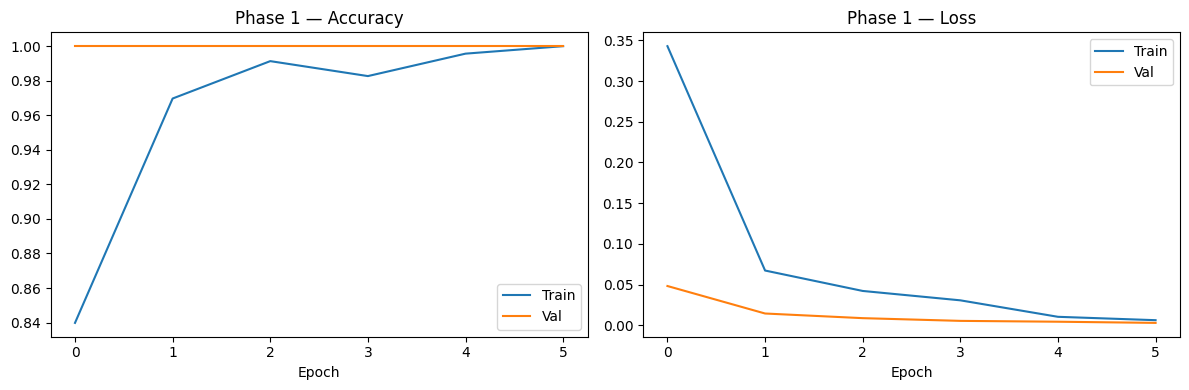

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history1.history['accuracy'], label='Train')
axes[0].plot(history1.history['val_accuracy'], label='Val')
axes[0].set_title('Phase 1 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history1.history['loss'], label='Train')
axes[1].plot(history1.history['val_loss'], label='Val')
axes[1].set_title('Phase 1 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Phase 2 — Fine-Tuning

In [13]:
# Unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Fine-tuning from layer {fine_tune_from} / {len(base_model.layers)}")
print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Starting Phase 2 fine-tuning...")


Fine-tuning from layer 124 / 154
Trainable layers: 7
Starting Phase 2 fine-tuning...


In [14]:
history2 = model.fit(
    train_ds_aug,
    validation_data=val_ds_prep,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2,
    verbose=1
)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 461ms/step - accuracy: 0.9221 - loss: 0.2194 - precision: 0.8932 - recall: 0.9293 - val_accuracy: 1.0000 - val_loss: 0.0171 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 772ms/step - accuracy: 1.0000 - loss: 0.0261 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0060 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 495ms/step - accuracy: 1.0000 - loss: 0.0123 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0042 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step - accuracy: 1.0000 - loss: 0.0063 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0035 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 519ms

### Phase 2 Learning Curves

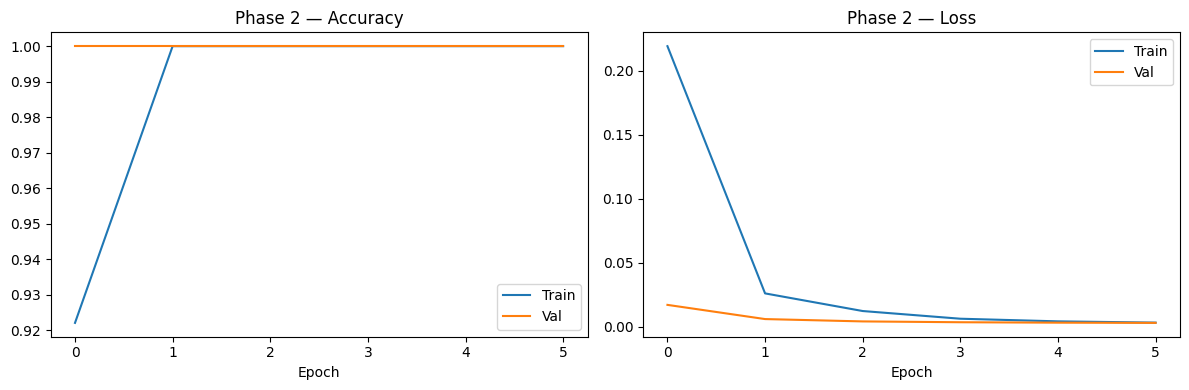

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history2.history['accuracy'], label='Train')
axes[0].plot(history2.history['val_accuracy'], label='Val')
axes[0].set_title('Phase 2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history2.history['loss'], label='Train')
axes[1].plot(history2.history['val_loss'], label='Val')
axes[1].set_title('Phase 2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluation on Test Set

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 574ms/step

=== Classification Report ===
              precision    recall  f1-score   support

Healthy skin       0.79      1.00      0.88        22
    Ringworm       1.00      0.79      0.88        29

    accuracy                           0.88        51
   macro avg       0.89      0.90      0.88        51
weighted avg       0.91      0.88      0.88        51



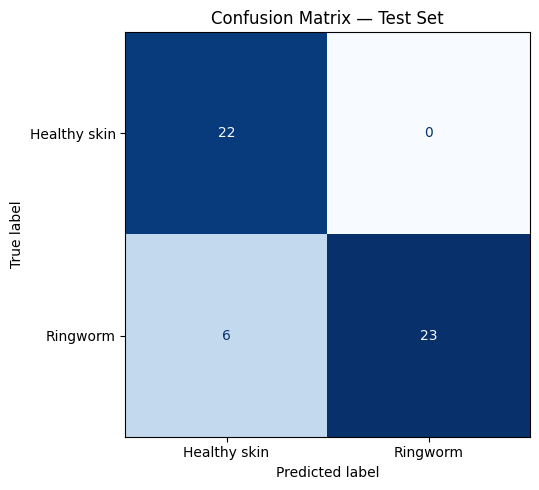

In [16]:
# Get all test labels and predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds_prep]).flatten()
y_pred_prob = model.predict(test_ds_prep).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


## 8. Save Model

In [17]:
model.save('ringworm_binary_classifier.keras')
print("Model saved as ringworm_binary_classifier.keras")


Model saved as ringworm_binary_classifier.keras


## 9. Summary

In [18]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds_prep, verbose=0)
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-8)

print("=" * 40)
print(f"Test Accuracy  : {test_acc*100:.2f}%")
print(f"Test Precision : {test_prec*100:.2f}%")
print(f"Test Recall    : {test_rec*100:.2f}%")
print(f"Test F1-Score  : {f1*100:.2f}%")
print("=" * 40)


Test Accuracy  : 88.24%
Test Precision : 100.00%
Test Recall    : 79.31%
Test F1-Score  : 88.46%
